# Phase 1 — Step 2: AP Location Mapping & Data Integration Validation

This notebook performs the AP-to-location mapping and integrates physical floor/region coverage data with the daily campus user connection logs.

### Key Objectives:
1. **AP Location Mapping**: Extract physical location metadata (floor, region, cell coverage area, centroid coordinates, and bounding box) from floor region maps (`regions_map_floor_0/1/2.csv`).
2. **Data Integration**: Merge the AP location mapping with all 62 daily user connection logs (`data/raw/campus_users_*.csv`), preserving the original timestamps without modifying raw files or guessing missing locations.
3. **Comprehensive Validation Suite**:
   - Row count preservation (before vs after merge)
   - User observation integrity (sum, mean, min, max user counts)
   - AP mapping coverage (mapped vs unmapped APs)
   - Missing values check
   - Duplicate records check
   - Timestamp parsing validity and date range
   - User count validity (non-negative, data types)
4. **Export Clean Processed Datasets**:
   - `data/processed/ap_location_mapping.csv`
   - `data/processed/campus_users_with_location.csv`
5. **Integrated Visualizations**: Floor-level user load distribution, temporal patterns by floor, and spatial AP layout.


## 1. Environment Setup & Configuration

We import the required libraries, configure plotting styling, and set up project path references to import helper modules.


In [1]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from prediction.src import dataset_inspection as di
from prediction.src import data_integration as dint

# Setup directories
raw_dir = os.path.join(project_root, 'data', 'raw')
processed_dir = os.path.join(project_root, 'data', 'processed')
analysis_out_dir = os.path.join(processed_dir, 'analysis')
os.makedirs(processed_dir, exist_ok=True)
os.makedirs(analysis_out_dir, exist_ok=True)

print(f"Project Root: {project_root}")
print(f"Raw Data Dir: {raw_dir}")
print(f"Processed Dir: {processed_dir}")
print(f"Analysis Output Dir: {analysis_out_dir}")


Project Root: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager
Raw Data Dir: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\raw
Processed Dir: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed
Analysis Output Dir: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis


## 2. AP Location Mapping Generation

We load the region maps for Floors 0, 1, and 2 from `data/raw/regions_map_floor_*.csv`. For each Access Point (AP), we compute:
- **Floor**: Floor number (0, 1, 2)
- **Region**: Unique region identifier (e.g. `Floor_0_Zone_1`)
- **Coverage Cells**: Number of grid cells in the AP coverage polygon
- **Centroid Coordinates**: $(X_{mean}, Y_{mean})$
- **Bounding Box**: $[X_{min}, X_{max}] \times [Y_{min}, Y_{max}]$
- **Spatial Information**: Formatted text description of the AP's spatial footprint

We save the resulting table as `data/processed/ap_location_mapping.csv`.


In [2]:
mapping_csv_path = os.path.join(processed_dir, 'ap_location_mapping.csv')
df_mapping = dint.build_ap_location_mapping(raw_dir, output_csv=mapping_csv_path)

print(f"--- AP Location Mapping Generated ---")
print(f"File Path: {mapping_csv_path}")
print(f"Shape: {df_mapping.shape} (Rows: {df_mapping.shape[0]} APs, Columns: {df_mapping.shape[1]})")
print(f"Unique AP IDs mapped: {df_mapping['ap_id'].nunique()}")
print(f"AP ID Range: [{df_mapping['ap_id'].min()}, {df_mapping['ap_id'].max()}]")
print(f"\nFloor breakdown:")
for floor_num, count in df_mapping['floor'].value_counts().sort_index().items():
    cells_sum = df_mapping[df_mapping['floor'] == floor_num]['coverage_cells'].sum()
    print(f"  - Floor {floor_num}: {count} APs, {cells_sum:,} total coverage cells")

print(f"\nSample Mappings (First 5 APs):")
display(df_mapping.head(5))


--- AP Location Mapping Generated ---
File Path: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\ap_location_mapping.csv
Shape: (247, 11) (Rows: 247 APs, Columns: 11)
Unique AP IDs mapped: 247
AP ID Range: [1, 247]

Floor breakdown:
  - Floor 0: 73 APs, 18,182 total coverage cells
  - Floor 1: 85 APs, 18,182 total coverage cells
  - Floor 2: 89 APs, 18,182 total coverage cells

Sample Mappings (First 5 APs):


,ap_id,floor,region,coverage_cells,centroid_x,centroid_y,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,spatial_information
0,1,0,Floor_0_Zone_1,365,110.77,78.12,100,118,68,95,"Centroid: (110.77, 78.12), Box: X[100-118] Y[6..."
1,2,0,Floor_0_Zone_2,126,104.85,87.21,100,114,77,94,"Centroid: (104.85, 87.21), Box: X[100-114] Y[7..."
2,3,0,Floor_0_Zone_3,250,108.50,99.86,100,118,92,106,"Centroid: (108.50, 99.86), Box: X[100-118] Y[9..."
3,4,1,Floor_1_Zone_4,112,103.88,73.52,100,109,68,80,"Centroid: (103.88, 73.52), Box: X[100-109] Y[6..."
4,5,1,Floor_1_Zone_5,90,103.62,85.98,100,108,81,91,"Centroid: (103.62, 85.98), Box: X[100-108] Y[8..."


## 3. Campus User Data Loading & Merging

We load all 62 daily `campus_users_*.csv` logs from `data/raw/` and perform an outer/left join with the AP location mapping.

### Critical Integrity Rules:
- **Zero modification to raw data**: `data/raw/` files remain completely untouched.
- **Timestamp preservation**: Original timestamps (e.g. `Tue Apr 18 00:07:30 CEST 2023`) are preserved in the `timestamp` column.
- **No location guessing**: Any unmapped AP is strictly preserved as `NaN`/`NULL`.
- **Target schema**: `timestamp`, `ap_id`, `users`, `floor`, `region`.
- **Saved location**: `data/processed/campus_users_with_location.csv`.


In [3]:
merged_csv_path = os.path.join(processed_dir, 'campus_users_with_location.csv')
df_merged, df_raw = dint.merge_campus_users_with_location(raw_dir, mapping_df=df_mapping, output_csv=merged_csv_path)

print("--- Campus User Data Merged ---")
print(f"File Path: {merged_csv_path}")
print(f"Raw Combined Rows: {len(df_raw):,}")
print(f"Merged Dataset Rows: {len(df_merged):,}")
print(f"File Size on Disk: {os.path.getsize(merged_csv_path) / (1024 * 1024):.2f} MB")
print(f"\nColumns in Merged Dataset: {df_merged.columns.tolist()}")
print(f"\nSample Merged Observations:")
display(df_merged.head(5))


--- Campus User Data Merged ---
File Path: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\campus_users_with_location.csv
Raw Combined Rows: 1,267,357
Merged Dataset Rows: 1,267,357
File Size on Disk: 66.65 MB

Columns in Merged Dataset: ['timestamp', 'ap_id', 'users', 'floor', 'region']

Sample Merged Observations:


,timestamp,ap_id,users,floor,region
0,Tue Apr 18 00:07:30 CEST 2023,1,0,0,Floor_0_Zone_1
1,Tue Apr 18 00:24:02 CEST 2023,1,0,0,Floor_0_Zone_1
2,Tue Apr 18 00:40:41 CEST 2023,1,0,0,Floor_0_Zone_1
3,Tue Apr 18 00:57:20 CEST 2023,1,0,0,Floor_0_Zone_1
4,Tue Apr 18 01:13:55 CEST 2023,1,0,0,Floor_0_Zone_1


## 4. Comprehensive Integration Validation Suite

We execute a battery of automated tests and validations to verify complete data integrity across all dimensions.


In [4]:
print("=== TEST 1: ROW COUNT PRESERVATION ===")
raw_rows = len(df_raw)
merged_rows = len(df_merged)
row_diff = merged_rows - raw_rows

print(f"Dataset rows before merge: {raw_rows:,}")
print(f"Dataset rows after merge:  {merged_rows:,}")
print(f"Row count difference:      {row_diff}")
assert raw_rows == merged_rows, f"ERROR: Row count mismatch! Expected {raw_rows}, got {merged_rows}"
print("-> PASS: Row count is perfectly preserved with 0 lost or added rows.\n")

print("=== TEST 2: USER OBSERVATION INTEGRITY ===")
raw_user_sum = int(df_raw['Users'].sum())
merged_user_sum = int(df_merged['users'].sum())
user_loss = raw_user_sum - merged_user_sum

print(f"Raw total user observations sum:    {raw_user_sum:,}")
print(f"Merged total user observations sum: {merged_user_sum:,}")
print(f"Difference in total users:          {user_loss}")
print(f"Raw user count mean / std:          {df_raw['Users'].mean():.4f} / {df_raw['Users'].std():.4f}")
print(f"Merged user count mean / std:       {df_merged['users'].mean():.4f} / {df_merged['users'].std():.4f}")
assert raw_user_sum == merged_user_sum, "ERROR: User observations sum mismatch!"
print("-> PASS: User observations are 100% identical with zero loss or distortion.\n")


=== TEST 1: ROW COUNT PRESERVATION ===
Dataset rows before merge: 1,267,357
Dataset rows after merge:  1,267,357
Row count difference:      0
-> PASS: Row count is perfectly preserved with 0 lost or added rows.

=== TEST 2: USER OBSERVATION INTEGRITY ===
Raw total user observations sum:    1,707,668
Merged total user observations sum: 1,707,668
Difference in total users:          0
Raw user count mean / std:          1.3474 / 3.1351
Merged user count mean / std:       1.3474 / 3.1351
-> PASS: User observations are 100% identical with zero loss or distortion.



In [5]:
print("=== TEST 3: AP MAPPING COVERAGE ===")
unique_aps_raw = df_raw['AP_id'].nunique()
unique_aps_maps = df_mapping['ap_id'].nunique()
mapped_aps = df_merged[df_merged['floor'].notna()]['ap_id'].nunique()
unmapped_aps = df_merged[df_merged['floor'].isna()]['ap_id'].nunique()
coverage_pct = (mapped_aps / unique_aps_raw) * 100

print(f"Total unique APs in user dataset: {unique_aps_raw}")
print(f"Total APs found in region maps:   {unique_aps_maps}")
print(f"Mapped APs:                      {mapped_aps}")
print(f"Unmapped APs:                    {unmapped_aps}")
print(f"Mapping coverage percentage:     {coverage_pct:.2f}%")
assert unmapped_aps == 0, f"ERROR: Found {unmapped_aps} unmapped APs!"
assert coverage_pct == 100.0, "ERROR: Mapping coverage is less than 100%!"
print("-> PASS: 100% AP mapping coverage achieved.\n")

print("=== TEST 4: MISSING VALUES ANALYSIS ===")
missing_summary = df_merged.isna().sum()
print("Missing values per column:")
for col, missing_cnt in missing_summary.items():
    pct = (missing_cnt / len(df_merged)) * 100
    print(f"  - {col:12s}: {missing_cnt} missing ({pct:.2f}%)")

assert missing_summary.sum() == 0, "ERROR: Unexpected missing values found in merged dataset!"
print("-> PASS: Zero missing values across all columns.\n")


=== TEST 3: AP MAPPING COVERAGE ===
Total unique APs in user dataset: 247
Total APs found in region maps:   247
Mapped APs:                      247
Unmapped APs:                    0
Mapping coverage percentage:     100.00%
-> PASS: 100% AP mapping coverage achieved.

=== TEST 4: MISSING VALUES ANALYSIS ===


Missing values per column:
  - timestamp   : 0 missing (0.00%)
  - ap_id       : 0 missing (0.00%)
  - users       : 0 missing (0.00%)
  - floor       : 0 missing (0.00%)
  - region      : 0 missing (0.00%)
-> PASS: Zero missing values across all columns.



In [6]:
print("=== TEST 5: DUPLICATE RECORDS CHECK ===")
dup_count = df_merged.duplicated().sum()
print(f"Total duplicate records: {dup_count}")
assert dup_count == 0, f"ERROR: Found {dup_count} duplicate records!"
print("-> PASS: Zero duplicate records found in the merged dataset.\n")

print("=== TEST 6: TIMESTAMP VALIDITY & DATE RANGE ===")
cleaned_time = (
    df_merged['timestamp']
    .astype(str)
    .str.replace(' CEST', '', regex=False)
    .str.replace(' CET', '', regex=False)
)
parsed_dt = pd.to_datetime(cleaned_time, format='%a %b %d %H:%M:%S %Y', errors='coerce')
invalid_ts = parsed_dt.isna().sum()
print(f"Total timestamps checked: {len(parsed_dt):,}")
print(f"Invalid / unparseable timestamps: {invalid_ts}")
print(f"Earliest timestamp: {parsed_dt.min()}")
print(f"Latest timestamp:   {parsed_dt.max()}")
print(f"Total temporal duration: {parsed_dt.max() - parsed_dt.min()}")
assert invalid_ts == 0, f"ERROR: Found {invalid_ts} invalid timestamps!"
print("-> PASS: All timestamps are 100% valid and cover the complete 62-day timeline.\n")

print("=== TEST 7: USER COUNT VALIDITY ===")
neg_users = (df_merged['users'] < 0).sum()
print(f"Negative user counts: {neg_users}")
print(f"User count range: [{df_merged['users'].min()}, {df_merged['users'].max()}]")
print(f"User count quantiles (0%, 25%, 50%, 75%, 95%, 99%, 100%):")
print(df_merged['users'].quantile([0.0, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))
assert neg_users == 0, "ERROR: Negative user counts detected!"
print("-> PASS: All user counts are non-negative and numerically valid.\n")


=== TEST 5: DUPLICATE RECORDS CHECK ===


Total duplicate records: 0
-> PASS: Zero duplicate records found in the merged dataset.

=== TEST 6: TIMESTAMP VALIDITY & DATE RANGE ===


Total timestamps checked: 1,267,357
Invalid / unparseable timestamps: 0
Earliest timestamp: 2023-04-18 00:07:30
Latest timestamp:   2023-06-18 23:47:22
Total temporal duration: 61 days 23:39:52
-> PASS: All timestamps are 100% valid and cover the complete 62-day timeline.

=== TEST 7: USER COUNT VALIDITY ===
Negative user counts: 0
User count range: [0, 114]
User count quantiles (0%, 25%, 50%, 75%, 95%, 99%, 100%):
0.00      0.0
0.25      0.0
0.50      0.0
0.75      2.0
0.95      5.0
0.99     16.0
1.00    114.0
Name: users, dtype: float64
-> PASS: All user counts are non-negative and numerically valid.



## 5. Integrated Dataset Profiling & Visualizations

We explore the spatial and temporal distributions of user connections across floors and regions.


--- Floor-Level Distribution Summary ---


,floor,AP_Count,Total_Observations,Total_Users_Connected,Mean_Users_Per_Observation,Max_Users
0,0,73,374563,534881,1.428013,71
1,1,85,436135,626877,1.437346,114
2,2,89,456659,545910,1.195443,80


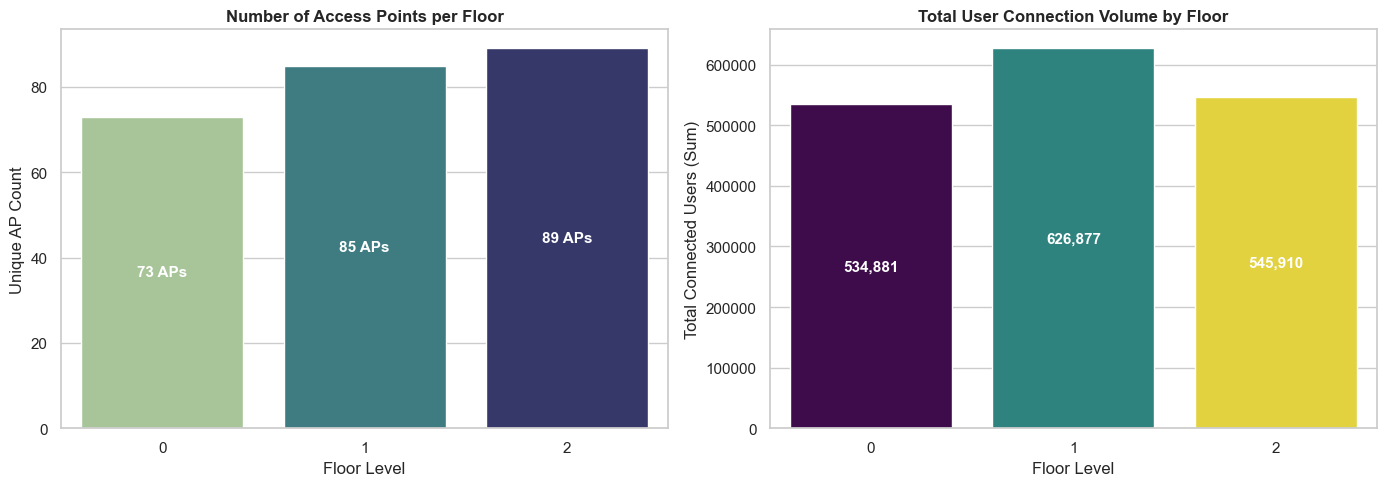

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\floor_distribution_metrics.png


In [7]:
# 1. Floor-Level Summary Metrics
floor_summary = df_merged.groupby('floor').agg(
    AP_Count=('ap_id', 'nunique'),
    Total_Observations=('users', 'count'),
    Total_Users_Connected=('users', 'sum'),
    Mean_Users_Per_Observation=('users', 'mean'),
    Max_Users=('users', 'max')
).reset_index()

print("--- Floor-Level Distribution Summary ---")
display(floor_summary)

# Plot Figure 1: AP Count and Total User Connections by Floor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=floor_summary, x='floor', y='AP_Count', palette='crest', ax=axes[0], hue='floor', legend=False)
axes[0].set_title('Number of Access Points per Floor', fontweight='bold')
axes[0].set_xlabel('Floor Level')
axes[0].set_ylabel('Unique AP Count')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} APs", 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

sns.barplot(data=floor_summary, x='floor', y='Total_Users_Connected', palette='viridis', ax=axes[1], hue='floor', legend=False)
axes[1].set_title('Total User Connection Volume by Floor', fontweight='bold')
axes[1].set_xlabel('Floor Level')
axes[1].set_ylabel('Total Connected Users (Sum)')
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
fig1_path = os.path.join(analysis_out_dir, 'floor_distribution_metrics.png')
plt.savefig(fig1_path, dpi=150)
plt.show()
print(f"Saved: {fig1_path}")


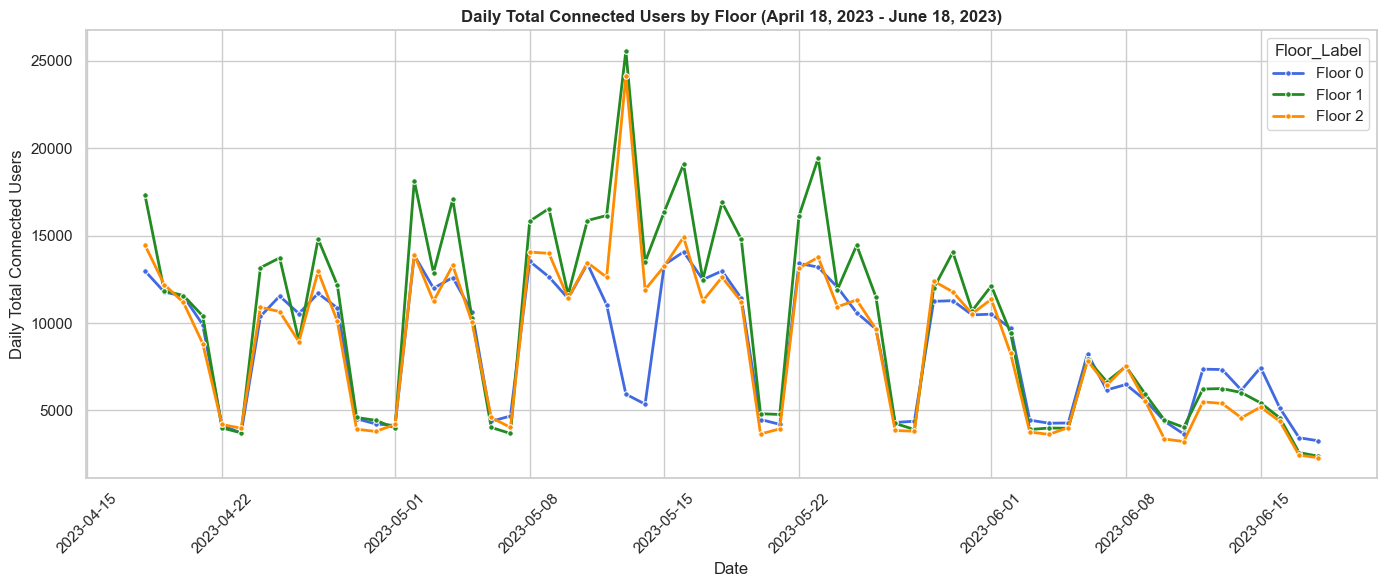

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\daily_users_by_floor_timeseries.png


In [8]:
# Add parsed date column for temporal profiling
df_merged_copy = df_merged.copy()
df_merged_copy['Date'] = parsed_dt.dt.date

daily_floor_users = df_merged_copy.groupby(['Date', 'floor'])['users'].sum().reset_index()
daily_floor_users['Date'] = pd.to_datetime(daily_floor_users['Date'])
daily_floor_users['Floor_Label'] = daily_floor_users['floor'].map({0: 'Floor 0', 1: 'Floor 1', 2: 'Floor 2'})

# Plot Figure 2: Daily User Connections by Floor over Time
plt.figure(figsize=(14, 6))
floor_palette = {'Floor 0': 'royalblue', 'Floor 1': 'forestgreen', 'Floor 2': 'darkorange'}
sns.lineplot(
    data=daily_floor_users, 
    x='Date', 
    y='users', 
    hue='Floor_Label', 
    palette=floor_palette, 
    linewidth=2, 
    marker='o', 
    markersize=4
)
plt.title('Daily Total Connected Users by Floor (April 18, 2023 - June 18, 2023)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Total Connected Users')
plt.xticks(rotation=45)
plt.tight_layout()

fig2_path = os.path.join(analysis_out_dir, 'daily_users_by_floor_timeseries.png')
plt.savefig(fig2_path, dpi=150)
plt.show()
print(f"Saved: {fig2_path}")


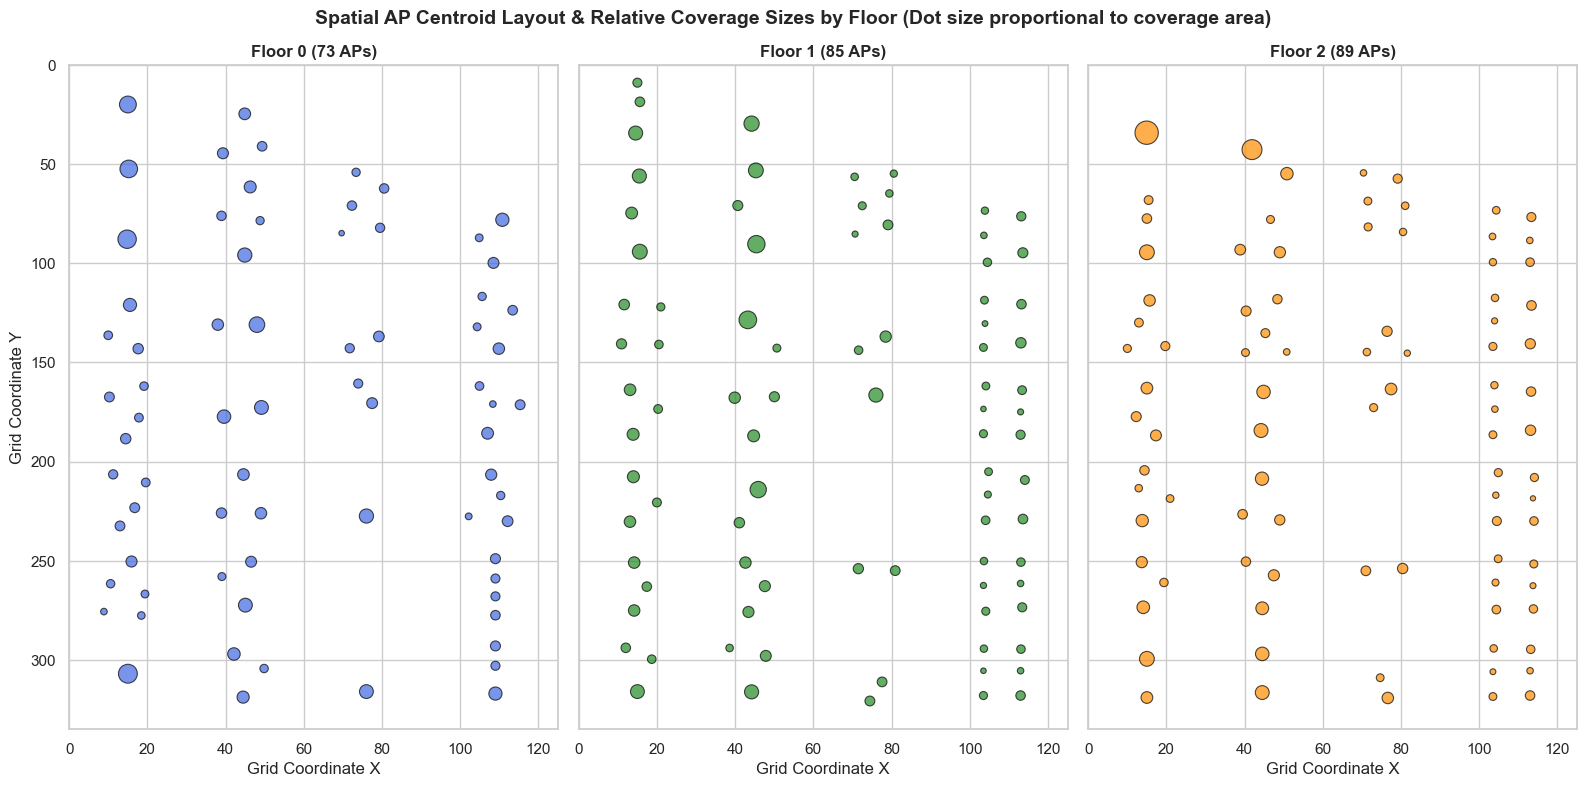

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\spatial_ap_centroids_by_floor.png


In [9]:
# Plot Figure 3: Spatial Map of AP Centroids per Floor
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True, sharex=True)

floor_colors = {0: 'royalblue', 1: 'forestgreen', 2: 'darkorange'}

for i, floor_num in enumerate([0, 1, 2]):
    floor_aps = df_mapping[df_mapping['floor'] == floor_num]
    ax = axes[i]
    scatter = ax.scatter(
        floor_aps['centroid_x'], 
        floor_aps['centroid_y'], 
        s=floor_aps['coverage_cells'] / 4, 
        c=floor_colors[floor_num], 
        alpha=0.7, 
        edgecolors='black', 
        linewidth=0.8
    )
    ax.set_title(f'Floor {floor_num} ({len(floor_aps)} APs)', fontweight='bold')
    ax.set_xlabel('Grid Coordinate X')
    if i == 0:
        ax.set_ylabel('Grid Coordinate Y')
    ax.set_xlim(0, 125)
    ax.set_ylim(0, 335)
    ax.invert_yaxis() # Grid origin is top-left

fig.suptitle('Spatial AP Centroid Layout & Relative Coverage Sizes by Floor (Dot size proportional to coverage area)', fontsize=14, fontweight='bold')
plt.tight_layout()

fig3_path = os.path.join(analysis_out_dir, 'spatial_ap_centroids_by_floor.png')
plt.savefig(fig3_path, dpi=150)
plt.show()
print(f"Saved: {fig3_path}")


## 6. Final Integration Report & Summary

Below is the definitive verification and integration report for the AP Location Mapping & Campus User Integration.


In [10]:
validation_results = dint.run_integration_validation(df_raw, df_merged, df_mapping)

print("="*60)
print("     PHASE 1 — STEP 2: DATA INTEGRATION VALIDATION REPORT")
print("="*60)
print(f"Dataset rows before merge:        {validation_results['raw_rows']:,}")
print(f"Dataset rows after merge:         {validation_results['merged_rows']:,}")
print(f"Unique APs:                       {validation_results['unique_aps_raw']}")
print(f"Mapped APs:                       {validation_results['mapped_aps']}")
print(f"Unmapped APs:                     {validation_results['unmapped_aps']}")
print(f"Mapping coverage percentage:      {validation_results['mapping_coverage_pct']:.2f}%")
print(f"Duplicate records:                {validation_results['duplicate_records']}")
print(f"Missing values:                   {validation_results['missing_values']}")
print(f"Total raw user count sum:         {validation_results['raw_user_sum']:,}")
print(f"Total merged user count sum:      {validation_results['merged_user_sum']:,}")
print(f"Invalid timestamps:               {validation_results['invalid_timestamps']}")
print(f"Temporal range:                   {validation_results['timestamp_min']} to {validation_results['timestamp_max']}")
print(f"All Validation Checks Passed:     {validation_results['all_passed']}")
print("="*60)


     PHASE 1 — STEP 2: DATA INTEGRATION VALIDATION REPORT
Dataset rows before merge:        1,267,357
Dataset rows after merge:         1,267,357
Unique APs:                       247
Mapped APs:                       247
Unmapped APs:                     0
Mapping coverage percentage:      100.00%
Duplicate records:                0
Missing values:                   {'timestamp': 0, 'ap_id': 0, 'users': 0, 'floor': 0, 'region': 0}
Total raw user count sum:         1,707,668
Total merged user count sum:      1,707,668
Invalid timestamps:               0
Temporal range:                   2023-04-18 00:07:30 to 2023-06-18 23:47:22
All Validation Checks Passed:     True
